In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from scipy import signal
from scipy.signal import detrend, windows
import glob


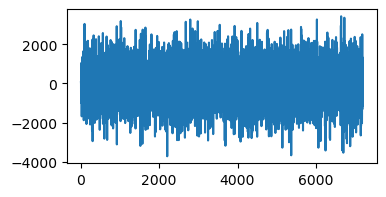

In [10]:
nfiles = len(glob.glob("/scratch/tolugboj_lab/Prj_Wavenet/epic_production/test_results_force_v2/*R2_Z.txt"))
for i in range(1, nfiles+1):
    #r1_file = f"raw timeseries/WAVE_SIM_{i:06d}_R1_Z.txt"
    r2_file = f"/scratch/tolugboj_lab/Prj_Wavenet/epic_production/test_results_force_v2/WAVE_SIM_{i:06d}_R1_Z.txt"
    
    #r1 = np.loadtxt(r1_file)
    r2 = np.loadtxt(r2_file)

    plt.figure(figsize=(4,2))
    plt.plot(r2)
    #print(r1.shape)

In [4]:
def moving_average_numpy(data, window_size):
    kernel = np.ones(window_size) / window_size
    smoothed_data = np.convolve(data, kernel, mode='same')
    return smoothed_data

def process_signals(data_array, taper_percent=0.05):
    detrended_data = detrend(data_array)
    taper_window = windows.tukey(len(detrended_data), alpha=taper_percent)
    tapered_data = detrended_data * taper_window

    return tapered_data

# Function to compute cross-power spectrum
def compute_cross_power_spectrum(r1, r2, delta):
    # Compute FFTs
    fft_r1 = np.fft.fft(r1)
    fft_r2 = np.fft.fft(r2)

    # Cross-power spectrum = FFT(R1) * conj(FFT(R2))
    cross_power = fft_r1 * np.conj(fft_r2)

    # Frequency axis
    freqs = np.fft.fftfreq(len(r1), d=delta)

    pos_mask = freqs > 0
    freqs_pos = freqs[pos_mask]
    # cross_power_pos = cross_power[pos_mask]

    # magnitude = np.abs(cross_power_pos)
    # coherence = cross_power/(np.abs(fft_r1)*np.abs(fft_r2))
    den = np.abs(fft_r1) * np.abs(fft_r2)
    coherence = np.zeros_like(cross_power, dtype=np.complex128)
    mask = den > 0
    coherence[mask] = cross_power[mask] / den[mask]

    return freqs_pos, cross_power[pos_mask],  coherence[pos_mask]

Loaded Wedge 1: R1=7199 samples, R2=7199 samples


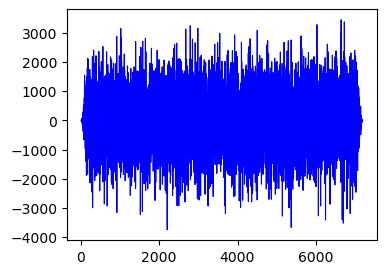

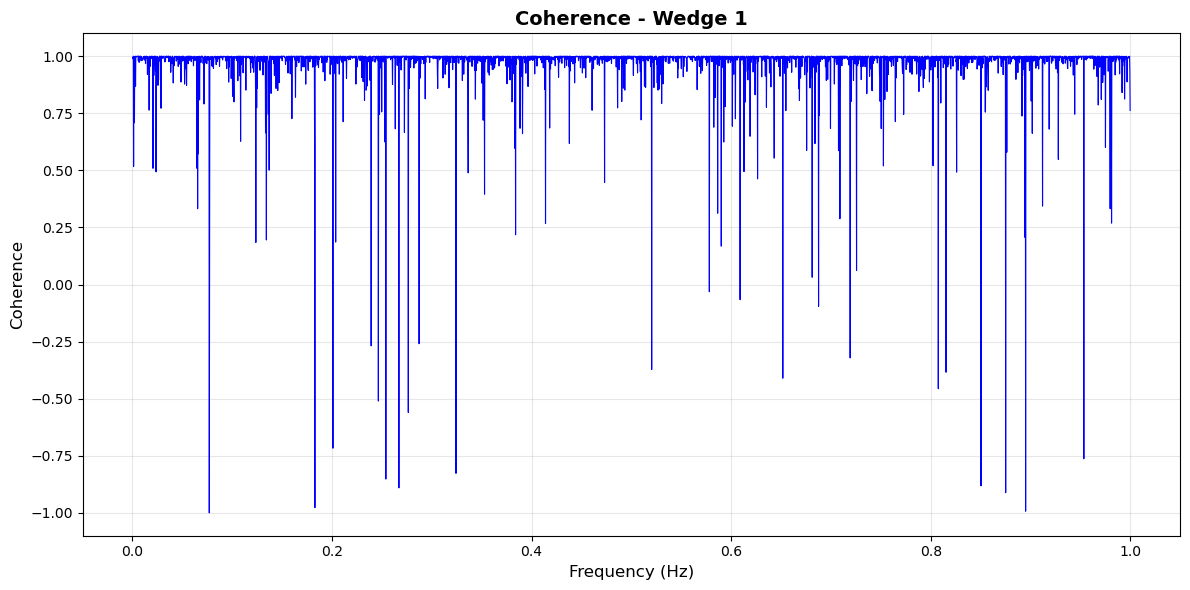

(1, 3599)


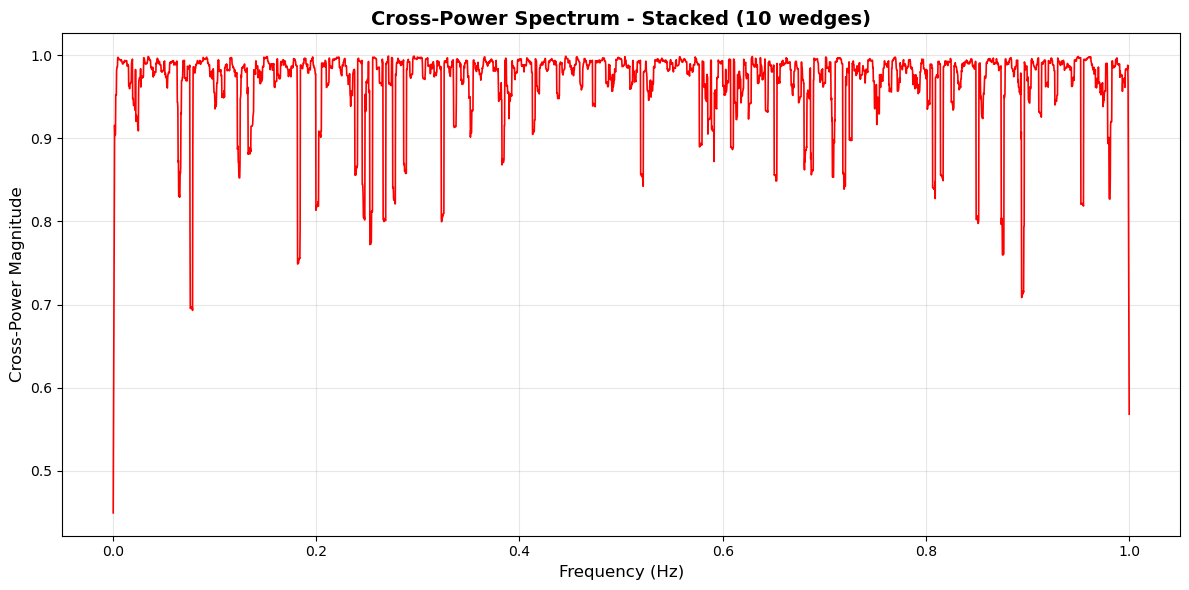

In [7]:
DELTA = 0.5 

wedges_r1_ts = []
wedges_r2_ts = []
wedges_freq_ccf = []
wedges_freq_axis = []
nfiles = len(glob.glob('/scratch/tolugboj_lab/Prj_Wavenet/epic_production/test_results_force_v2/*_R1_Z.txt'))

for i in range(1, nfiles+1):
    r1_file = f'/scratch/tolugboj_lab/Prj_Wavenet/epic_production/test_results_force_v2/WAVE_SIM_{i:06d}_R1_Z.txt'
    r2_file = f'/scratch/tolugboj_lab/Prj_Wavenet/epic_production/test_results_force_v2/WAVE_SIM_{i:06d}_R2_Z.txt'

    r1 = np.loadtxt(r1_file)
    r2 = np.loadtxt(r2_file)
    r1 = np.array(r1)
    r2 = np.array(r2)

    r1 = process_signals(r1)
    r2 = process_signals(r2)
    plt.figure(figsize=(4, 3))
    plt.plot(r1, 'b-', linewidth=0.8)
    
    wedges_r1_ts.append(r1)
    wedges_r2_ts.append(r2)

    print(f"Loaded Wedge {i}: R1={len(r1)} samples, R2={len(r2)} samples")

    # Compute cross-power spectrum
    freqs, cross_power, coherence = compute_cross_power_spectrum(r1, r2, DELTA)
    wedges_freq_ccf.append(coherence)
    wedges_freq_axis.append(freqs)
    
    # Create individual plot
    plt.figure(figsize=(12, 6))
    plt.plot(freqs, np.real(coherence), 'b-', linewidth=0.8)
    plt.xlabel('Frequency (Hz)', fontsize=12)
    plt.ylabel('Coherence', fontsize=12)
    plt.title(f'Coherence - Wedge {i}', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    #plt.xlim(0, 0.5)  # Focus on 0-0.5 Hz (typical surface wave range)
    plt.tight_layout()

    #output_file = f'./cross_power_spectrum_plots/Wedge_{i:02d}_cross_power.png'
    #plt.savefig(output_file, dpi=150, bbox_inches='tight')
    #print(f"  Saved: {output_file}")
    #plt.close()
    plt.show()

    if i==5:
        break

# Compute stacked cross-power spectrum (mean of all wedges)
# stacked_r1 = np.mean(wedges_r1, axis=0)
# stacked_r2 = np.mean(wedges_r2, axis=0)
# print(f"\nComputed stacked: R1={len(stacked_r1)} samples, R2={len(stacked_r2)} samples")

# Compute cross-power spectrum for stacked
#freqs, cross_power, coherence = compute_cross_power_spectrum(stacked_r1, stacked_r2, DELTA)

print(np.array(wedges_freq_ccf).shape)
final_coherence_mean = np.mean(np.array(wedges_freq_ccf), axis=0)
final_coherence_mean = moving_average_numpy(final_coherence_mean, 10)
final_coherence_freqs = wedges_freq_axis[0]

# Create stacked plot
plt.figure(figsize=(12, 6))
plt.plot(final_coherence_freqs, np.real(final_coherence_mean), 'r-', linewidth=1.2)
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Cross-Power Magnitude', fontsize=12)
plt.title('Cross-Power Spectrum - Stacked (10 wedges)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
#plt.xlim(0, 0.5)  # Focus on 0-0.5 Hz
plt.tight_layout()

#output_stacked = './cross_power_spectrum_plots/Stacked_cross_power.png'
#plt.savefig(output_stacked, dpi=150, bbox_inches='tight')
#print(f"Saved: {output_stacked}")
#plt.close()
plt.show()